# E-Commerce Customer Behavior & Business Performance Analysis
### Brazilian E-Commerce Public Dataset by Olist (2016 - 2018)

--- 

## 1. Executive Summary & Project Background
Dataset ini berisi **99.441 pesanan riil** dari platform marketplace Olist di Brazil pada periode 2016 hingga 2018. Dataset ini mencakup berbagai dimensi bisnis: pelanggan (*customers*), pesanan (*orders*), item pesanan (*order items*), pembayaran (*payments*), ulasan pelanggan (*reviews*), produk (*products*), penjual (*sellers*), dan data geolokasi.

### Tujuan Analisis:
1. **Customer Behavior & Retention:** Menghitung rasio *repeat customer* dan melakukan segmentasi pelanggan berbasis *RFM (Recency, Frequency, Monetary)*.
2. **Product Performance:** Mengidentifikasi kategori produk unggulan (terlaris secara omzet/volume) serta kategori dengan kepuasan pelanggan tertinggi dan terendah.
3. **Delivery & Logistics Performance:** Mengevaluasi *on-time delivery rate* dan disparitas durasi pengiriman antar negara bagian di Brazil.
4. **Payment Preferences & Financing:** Menganalisis penetrasi metode pembayaran dan hubungan antara fasilitas cicilan (*installments*) terhadap nilai transaksi (*basket size*).
5. **Service Quality vs Satisfaction:** Memetakan korelasi empiris antara durasi pengiriman terhadap skor ulasan (*review score*) konsumen.
6. **Direct SQL Integration:** Mengeksekusi query relasional langsung terhadap database SQLite (`sql/olist.db`).

--- 
## 2. Environment Setup & Library Imports

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Environment initialized successfully!")

Environment initialized successfully!


--- 
## 3. Data Loading & Data Quality Checks (DQC)

Sesuai panduan kualitas data pada brief:
- Kolom tanggal pengiriman yang kosong pada tabel `orders` adalah **valid** (mencerminkan pesanan berstatus batal, diproses, atau belum sampai). Kita tidak boleh melakukan *drop rows* secara sembarangan.
- Terdapat 610 produk tanpa `product_category_name` yang dikategorikan sebagai `'unknown'`.
- Komentar ulasan bersifat opsional, namun `review_score` lengkap dan valid untuk seluruh ulasan.

In [2]:
DATA_DIR = '../data' if os.path.exists('../data') else 'data'

df_orders = pd.read_csv(os.path.join(DATA_DIR, 'olist_orders_dataset.csv'))
df_customers = pd.read_csv(os.path.join(DATA_DIR, 'olist_customers_dataset.csv'))
df_order_items = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_items_dataset.csv'))
df_payments = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_payments_dataset.csv'))
df_reviews = pd.read_csv(os.path.join(DATA_DIR, 'olist_order_reviews_dataset.csv'))
df_products = pd.read_csv(os.path.join(DATA_DIR, 'olist_products_dataset.csv'))
df_sellers = pd.read_csv(os.path.join(DATA_DIR, 'olist_sellers_dataset.csv'))
df_cat = pd.read_csv(os.path.join(DATA_DIR, 'product_category_name_translation.csv'))

# Parsing tanggal
date_cols_orders = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 
                    'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols_orders:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')

# Handling missing category
df_products['product_category_name'] = df_products['product_category_name'].fillna('unknown')

print("=== DATASET SHAPES ===")
print(f"Orders       : {df_orders.shape[0]:,} rows, {df_orders.shape[1]} cols")
print(f"Customers    : {df_customers.shape[0]:,} rows, {df_customers.shape[1]} cols")
print(f"Order Items  : {df_order_items.shape[0]:,} rows, {df_order_items.shape[1]} cols")
print(f"Payments     : {df_payments.shape[0]:,} rows, {df_payments.shape[1]} cols")
print(f"Reviews      : {df_reviews.shape[0]:,} rows, {df_reviews.shape[1]} cols")
print(f"Products     : {df_products.shape[0]:,} rows, {df_products.shape[1]} cols")
print(f"Sellers      : {df_sellers.shape[0]:,} rows, {df_sellers.shape[1]} cols")

=== DATASET SHAPES ===
Orders       : 99,441 rows, 8 cols
Customers    : 99,441 rows, 5 cols
Order Items  : 112,650 rows, 7 cols
Payments     : 103,886 rows, 5 cols
Reviews      : 99,224 rows, 7 cols
Products     : 32,951 rows, 9 cols
Sellers      : 3,095 rows, 4 cols


In [3]:
# Verifikasi Nilai Null pada Kolom Kritis
print("--- ORDERS MISSING DATES AUDIT ---")
print(df_orders[date_cols_orders].isnull().sum())
print("\n--- ORDER STATUS BREAKDOWN FOR MISSING DELIVERED DATES ---")
print(df_orders[df_orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts())

--- ORDERS MISSING DATES AUDIT ---
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

--- ORDER STATUS BREAKDOWN FOR MISSING DELIVERED DATES ---
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


> **DQC Insight:** Dari 2.965 pesanan yang tidak memiliki `order_delivered_customer_date`, mayoritas berstatus `shipped` (1.107), `canceled` (619), dan `unavailable` (609). Data ini membuktikan bahwa nilai null pada tanggal delivery bersifat valid secara bisnis dan tidak boleh di-drop.

--- 
## 4. Exploratory Data Analysis (EDA)

### Pertanyaan Bisnis 1: Customer Behavior & RFM Segmentation
- Berapa porsi *repeat customer* berdasarkan `customer_unique_id`?
- Bagaimana hasil segmentasi RFM pelanggan?

Total Unique Customers: 94,990
One-Time Customers    : 92,102 (96.96%)
Repeat Customers      : 2,888 (3.04%)


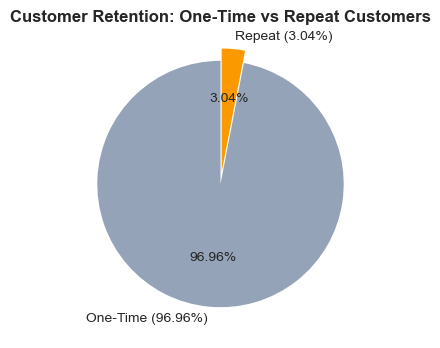

In [4]:
# Gabungkan orders dan customers untuk analisis repeat rate
valid_orders = df_orders[~df_orders['order_status'].isin(['canceled', 'unavailable'])]
cust_orders = valid_orders.merge(df_customers, on='customer_id')

customer_freq = cust_orders.groupby('customer_unique_id')['order_id'].nunique()
total_unique = len(customer_freq)
repeat_cust = (customer_freq > 1).sum()
one_time_cust = (customer_freq == 1).sum()
repeat_rate = (repeat_cust / total_unique) * 100

print(f"Total Unique Customers: {total_unique:,}")
print(f"One-Time Customers    : {one_time_cust:,} ({100 - repeat_rate:.2f}%)")
print(f"Repeat Customers      : {repeat_cust:,} ({repeat_rate:.2f}%)")

# Visualisasi Repeat Customer Rate
fig, ax = plt.subplots(figsize=(6, 4))
ax.pie([one_time_cust, repeat_cust], labels=['One-Time (96.96%)', 'Repeat (3.04%)'], 
       autopct='%1.2f%%', startangle=90, colors=['#94A3B8', '#FA9A00'], explode=(0, 0.1))
ax.set_title('Customer Retention: One-Time vs Repeat Customers', fontsize=12, fontweight='bold')
plt.show()

In [5]:
# RFM Segmentation Calculation
# Referensi waktu: Maksimum purchase date + 1 hari
ref_date = valid_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

cust_items = cust_orders.merge(df_order_items, on='order_id')
cust_items['total_value'] = cust_items['price'] + cust_items['freight_value']

rfm = cust_items.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (ref_date - x.max()).days,
    'order_id': 'nunique',
    'total_value': 'sum'
}).reset_index()

rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

# Skor RFM
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_Score'] = rfm['Frequency'].apply(lambda x: 1 if x == 1 else (3 if x == 2 else 5))
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

def segment_customer(row):
    r, f = row['R_Score'], row['F_Score']
    if r >= 4 and f >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 3:
        return 'At Risk / Need Attention'
    else:
        return 'Lost / Inactive'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm_summary = rfm.groupby('Segment').agg(
    Customer_Count=('customer_unique_id', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).reset_index()
rfm_summary['Pct_Customers'] = (rfm_summary['Customer_Count'] / len(rfm)) * 100
rfm_summary = rfm_summary.sort_values(by='Total_Revenue', ascending=False)
display(rfm_summary)

,Segment,Customer_Count,Avg_Recency,Avg_Monetary,Total_Revenue,Pct_Customers
5,Recent Customers,36817,95.71,164.75,6065488.54,38.76
2,Lost / Inactive,36886,401.05,162.27,5985570.07,38.83
4,Potential Loyalists,18393,225.68,151.92,2794253.21,19.36
3,Loyal Customers,1731,140.14,299.46,518365.85,1.82
0,At Risk / Need Attention,1027,388.74,293.85,301781.52,1.08
1,Champions,129,95.17,543.16,70067.84,0.14


--- 
### Pertanyaan Bisnis 2: Product Performance
- Kategori produk apa yang menghasilkan revenue tertinggi dan volume terlaris?
- Kategori apa yang memiliki rating kepuasan tertinggi dan terendah?

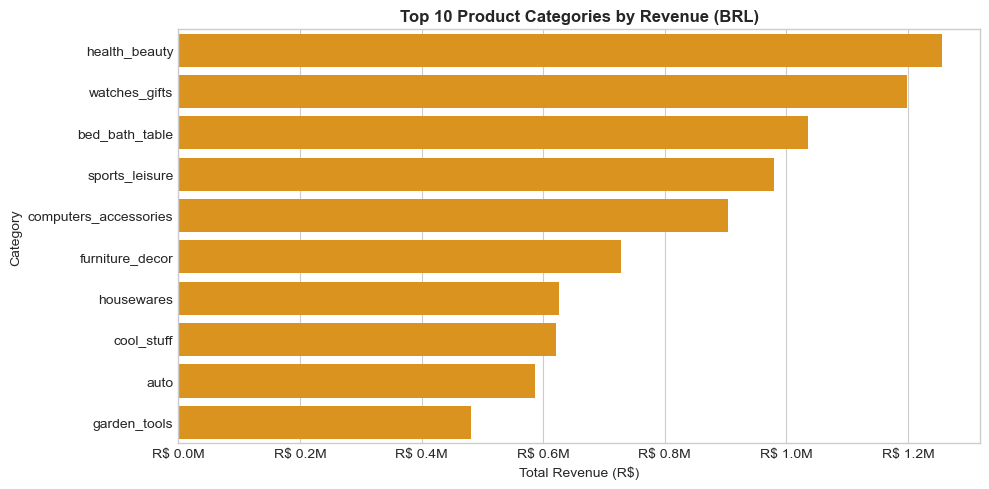

In [6]:
# Merge items dengan produk & translasi nama kategori
df_prod_trans = df_products.merge(df_cat, on='product_category_name', how='left')
df_prod_trans['category_name_english'] = df_prod_trans['product_category_name_english'].fillna(df_prod_trans['product_category_name'])

items_prod = df_order_items.merge(df_prod_trans, on='product_id', how='left')
items_prod_orders = items_prod.merge(valid_orders[['order_id']], on='order_id')

cat_performance = items_prod_orders.groupby('category_name_english').agg(
    Total_Orders=('order_id', 'nunique'),
    Items_Sold=('order_item_id', 'count'),
    Total_Revenue=('price', 'sum'),
    Avg_Price=('price', 'mean')
).reset_index().sort_values(by='Total_Revenue', ascending=False)

# Top 10 Kategori by Revenue
plt.figure(figsize=(10, 5))
top10_cat = cat_performance.head(10)
sns.barplot(data=top10_cat, x='Total_Revenue', y='category_name_english', color='#FA9A00')
plt.title('Top 10 Product Categories by Revenue (BRL)', fontsize=12, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Category')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x*1e-6:.1f}M'))
plt.tight_layout()
plt.show()

In [7]:
# Analisis Rating Review per Kategori (Min. 100 Ulasan)
reviews_prod = df_reviews.merge(items_prod[['order_id', 'category_name_english']].drop_duplicates(), on='order_id')
cat_ratings = reviews_prod.groupby('category_name_english').agg(
    Review_Count=('review_score', 'count'),
    Avg_Score=('review_score', 'mean')
).reset_index()

cat_ratings_filtered = cat_ratings[cat_ratings['Review_Count'] >= 100]
top5_rated = cat_ratings_filtered.sort_values(by='Avg_Score', ascending=False).head(5)
bottom5_rated = cat_ratings_filtered.sort_values(by='Avg_Score', ascending=True).head(5)

print("=== TOP 5 HIGHEST RATED CATEGORIES ===")
display(top5_rated)
print("=== TOP 5 LOWEST RATED CATEGORIES ===")
display(bottom5_rated)

=== TOP 5 HIGHEST RATED CATEGORIES ===


,category_name_english,Review_Count,Avg_Score
8,books_general_interest,508,4.46
10,books_technical,259,4.41
37,food_drink,228,4.39
53,luggage_accessories,1030,4.33
36,food,445,4.28


=== TOP 5 LOWEST RATED CATEGORIES ===


,category_name_english,Review_Count,Avg_Score
57,office_furniture,1268,3.62
30,fashion_male_clothing,111,3.70
4,audio,348,3.83
19,construction_tools_safety,166,3.85
47,home_confort,398,3.86


--- 
### Pertanyaan Bisnis 3: Delivery Performance
- Berapa *on-time delivery rate* secara keseluruhan?
- Bagaimana disparitas durasi pengiriman antar negara bagian (*state*)?

In [8]:
delivered_orders = df_orders[
    (df_orders['order_status'] == 'delivered') &
    (df_orders['order_delivered_customer_date'].notnull()) &
    (df_orders['order_estimated_delivery_date'].notnull())
].copy()

delivered_orders['actual_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']).dt.total_seconds() / 86400
delivered_orders['estimated_days'] = (delivered_orders['order_estimated_delivery_date'] - delivered_orders['order_purchase_timestamp']).dt.total_seconds() / 86400
delivered_orders['is_on_time'] = delivered_orders['order_delivered_customer_date'] <= delivered_orders['order_estimated_delivery_date']

total_del = len(delivered_orders)
on_time_count = delivered_orders['is_on_time'].sum()
late_count = total_del - on_time_count
on_time_rate = (on_time_count / total_del) * 100

print(f"Total Delivered Orders: {total_del:,}")
print(f"On-Time Deliveries    : {on_time_count:,} ({on_time_rate:.2f}%)")
print(f"Late Deliveries       : {late_count:,} ({100 - on_time_rate:.2f}%)")
print(f"Average Actual Delivery Duration : {delivered_orders['actual_days'].mean():.1f} days")
print(f"Average Estimated Delivery Window: {delivered_orders['estimated_days'].mean():.1f} days")

Total Delivered Orders: 96,470
On-Time Deliveries    : 88,644 (91.89%)
Late Deliveries       : 7,826 (8.11%)
Average Actual Delivery Duration : 12.6 days
Average Estimated Delivery Window: 23.7 days


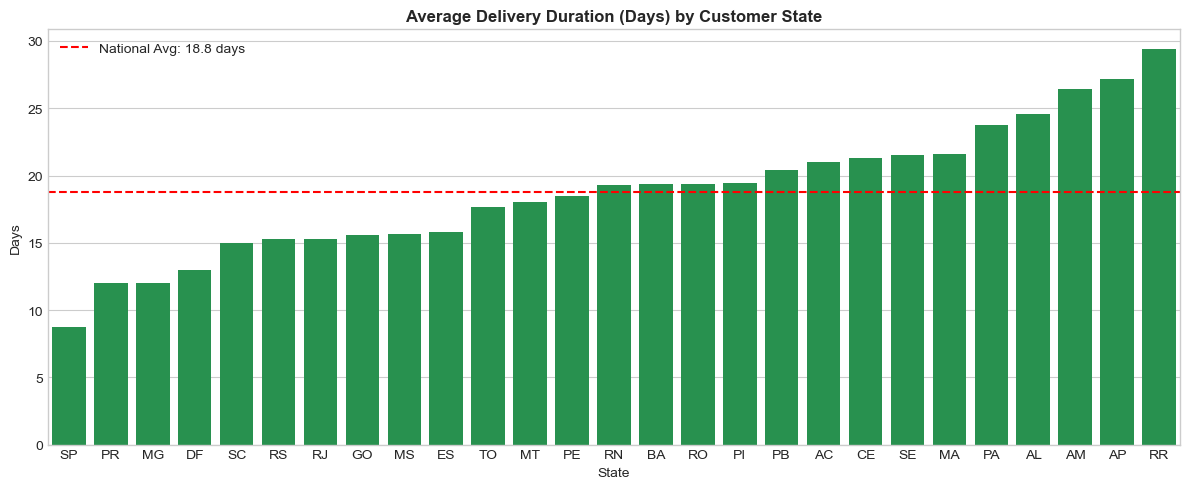

In [9]:
# Analisis Pengiriman Berdasarkan Customer State
del_state = delivered_orders.merge(df_customers[['customer_id', 'customer_state']], on='customer_id')
state_delivery = del_state.groupby('customer_state').agg(
    Total_Orders=('order_id', 'count'),
    Avg_Delivery_Days=('actual_days', 'mean'),
    On_Time_Rate=('is_on_time', lambda x: (x.sum() / len(x)) * 100)
).reset_index().sort_values(by='Avg_Delivery_Days', ascending=True)

plt.figure(figsize=(12, 5))
sns.barplot(data=state_delivery, x='customer_state', y='Avg_Delivery_Days', color='#16A34A')
plt.axhline(state_delivery['Avg_Delivery_Days'].mean(), color='red', linestyle='--', label=f"National Avg: {state_delivery['Avg_Delivery_Days'].mean():.1f} days")
plt.title('Average Delivery Duration (Days) by Customer State', fontsize=12, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Days')
plt.legend()
plt.tight_layout()
plt.show()

--- 
### Pertanyaan Bisnis 4: Payment Analysis & Installment Behavior
- Metode pembayaran apa yang paling dominan?
- Apakah jumlah cicilan (*installments*) berhubungan dengan nilai pesanan?

In [10]:
pay_summary = df_payments.groupby('payment_type').agg(
    Total_Orders=('order_id', 'nunique'),
    Total_Payment_Value=('payment_value', 'sum'),
    Avg_Payment_Value=('payment_value', 'mean'),
    Avg_Installments=('payment_installments', 'mean')
).reset_index()
pay_summary['Value_Share_Pct'] = (pay_summary['Total_Payment_Value'] / df_payments['payment_value'].sum()) * 100
pay_summary = pay_summary.sort_values(by='Total_Payment_Value', ascending=False)
display(pay_summary)

,payment_type,Total_Orders,Total_Payment_Value,Avg_Payment_Value,Avg_Installments,Value_Share_Pct
1,credit_card,76505,12542084.19,163.32,3.51,78.34
0,boleto,19784,2869361.27,145.03,1.00,17.92
4,voucher,3866,379436.87,65.70,1.00,2.37
2,debit_card,1528,217989.79,142.57,1.00,1.36
3,not_defined,3,0.00,0.00,1.00,0.00


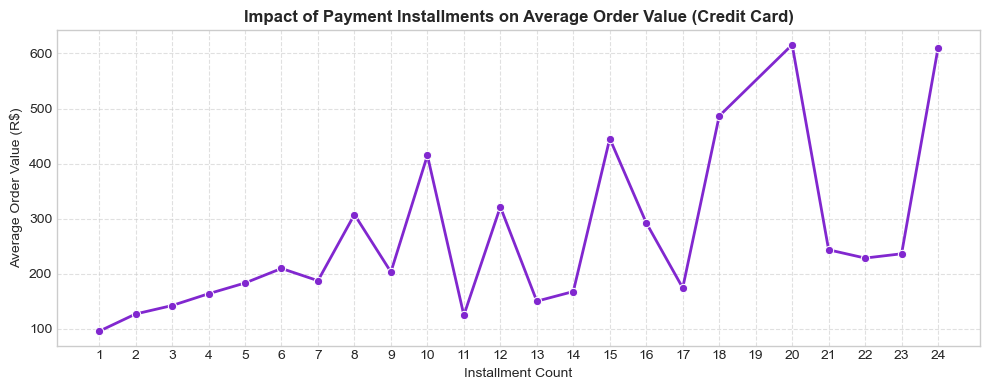

In [11]:
# Hubungan Jumlah Cicilan vs Nilai Rata-rata Order (Khusus Kartu Kredit)
cc_payments = df_payments[df_payments['payment_type'] == 'credit_card']
installment_analysis = cc_payments.groupby('payment_installments').agg(
    Order_Count=('order_id', 'nunique'),
    Avg_Value=('payment_value', 'mean')
).reset_index()

plt.figure(figsize=(10, 4))
sns.lineplot(data=installment_analysis[installment_analysis['payment_installments'] > 0], 
             x='payment_installments', y='Avg_Value', marker='o', color='#8127CF', linewidth=2)
plt.title('Impact of Payment Installments on Average Order Value (Credit Card)', fontsize=12, fontweight='bold')
plt.xlabel('Installment Count')
plt.ylabel('Average Order Value (R$)')
plt.xticks(range(1, 25))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

--- 
### Pertanyaan Bisnis 5: Delivery Time vs Review Score
- Apakah lamanya pengiriman secara signifikan menurunkan kepuasan pelanggan?

,delivery_bucket,Total_Orders,Avg_Review_Score,Pct_Score_5,Pct_Score_1
0,0-5 Days,13427,4.45,69.88,5.06
1,6-10 Days,33041,4.36,65.60,5.90
2,11-15 Days,23610,4.27,61.04,7.01
3,16-20 Days,12161,4.13,55.24,8.59
4,21-30 Days,9659,3.69,42.84,17.09
5,> 30 Days,4394,2.25,16.36,54.64


C:\Users\jasti\AppData\Local\Temp\ipykernel_30840\3936386235.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bucket_summary, x='delivery_bucket', y='Avg_Review_Score', ax=ax1, palette='Blues_d')


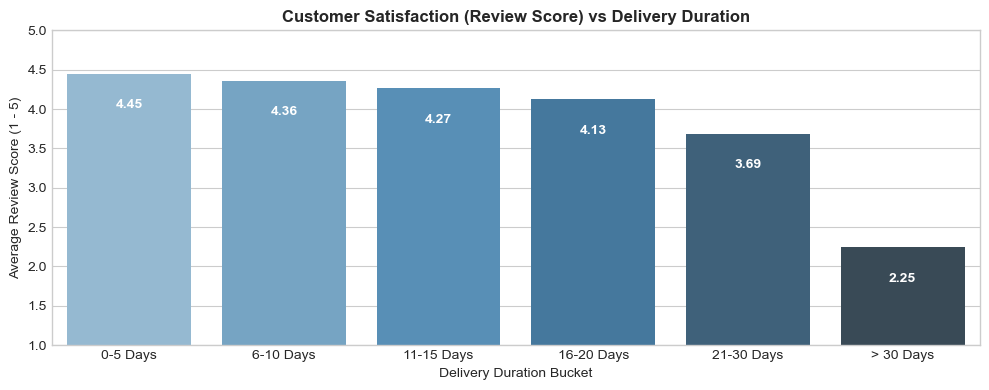

In [12]:
del_reviews = delivered_orders.merge(df_reviews[['order_id', 'review_score']], on='order_id')

# Binning durasi pengiriman
bins = [0, 5, 10, 15, 20, 30, 100]
labels = ['0-5 Days', '6-10 Days', '11-15 Days', '16-20 Days', '21-30 Days', '> 30 Days']
del_reviews['delivery_bucket'] = pd.cut(del_reviews['actual_days'], bins=bins, labels=labels)

bucket_summary = del_reviews.groupby('delivery_bucket', observed=False).agg(
    Total_Orders=('order_id', 'count'),
    Avg_Review_Score=('review_score', 'mean'),
    Pct_Score_5=('review_score', lambda x: (x == 5).sum() / len(x) * 100),
    Pct_Score_1=('review_score', lambda x: (x == 1).sum() / len(x) * 100)
).reset_index()

display(bucket_summary)

# Plot Korelasi
fig, ax1 = plt.subplots(figsize=(10, 4))
sns.barplot(data=bucket_summary, x='delivery_bucket', y='Avg_Review_Score', ax=ax1, palette='Blues_d')
ax1.set_title('Customer Satisfaction (Review Score) vs Delivery Duration', fontsize=12, fontweight='bold')
ax1.set_xlabel('Delivery Duration Bucket')
ax1.set_ylabel('Average Review Score (1 - 5)')
ax1.set_ylim(1, 5)
for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height() - 0.4),
                 ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

--- 
## 5. Direct SQL Integration (`sql/olist.db`)

Bagian ini menjalankan minimal 3 query SQL langsung dari file `sql/queries.sql` ke database SQLite `sql/olist.db`.

In [13]:
DB_PATH = '../sql/olist.db' if os.path.exists('../sql/olist.db') else 'sql/olist.db'
conn = sqlite3.connect(DB_PATH)

print(f"Connected to SQLite DB at: {DB_PATH}")

Connected to SQLite DB at: sql/olist.db


In [14]:
# SQL Query 1: Repeat Customer Rate
sql_q1 = """
WITH customer_order_counts AS (
    SELECT 
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS total_orders
    FROM customers c
    JOIN orders o ON c.customer_id = o.customer_id
    WHERE o.order_status NOT IN ('canceled', 'unavailable')
    GROUP BY c.customer_unique_id
)
SELECT 
    COUNT(*) AS total_unique_customers,
    SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) AS repeat_customers,
    SUM(CASE WHEN total_orders = 1 THEN 1 ELSE 0 END) AS one_time_customers,
    ROUND(100.0 * SUM(CASE WHEN total_orders > 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS repeat_customer_rate_pct
FROM customer_order_counts;
"""
df_sql_1 = pd.read_sql_query(sql_q1, conn)
print("=== SQL QUERY 1: REPEAT CUSTOMER RATE ===")
display(df_sql_1)

=== SQL QUERY 1: REPEAT CUSTOMER RATE ===


,total_unique_customers,repeat_customers,one_time_customers,repeat_customer_rate_pct
0,94990,2888,92102,3.04


In [15]:
# SQL Query 2: Top 10 Categories by Revenue with English Translation
sql_q2 = """
SELECT 
    COALESCE(ct.product_category_name_english, p.product_category_name, 'unknown') AS category_name,
    COUNT(DISTINCT oi.order_id) AS total_orders,
    COUNT(oi.order_item_id) AS total_items_sold,
    ROUND(SUM(oi.price), 2) AS total_sales_value,
    ROUND(AVG(oi.price), 2) AS avg_item_price
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
JOIN orders o ON oi.order_id = o.order_id
WHERE o.order_status NOT IN ('canceled', 'unavailable')
GROUP BY category_name
ORDER BY total_sales_value DESC
LIMIT 10;
"""
df_sql_2 = pd.read_sql_query(sql_q2, conn)
print("=== SQL QUERY 2: TOP 10 PRODUCT CATEGORIES ===")
display(df_sql_2)

=== SQL QUERY 2: TOP 10 PRODUCT CATEGORIES ===


,category_name,total_orders,total_items_sold,total_sales_value,avg_item_price
0,health_beauty,8800,9634,1255695.13,130.34
1,watches_gifts,5604,5970,1198185.21,200.70
2,bed_bath_table,9399,11097,1035964.06,93.36
3,sports_leisure,7673,8590,979740.92,114.06
4,computers_accessories,6654,7781,904322.02,116.22
5,furniture_decor,6425,8298,727465.05,87.67
6,housewares,5847,6915,626825.80,90.65
7,cool_stuff,3616,3779,620770.49,164.27
8,auto,3872,4204,586585.73,139.53
9,garden_tools,3505,4328,481009.94,111.14


In [16]:
# SQL Query 3: Delivery Time vs Review Score Analysis
sql_q3 = """
WITH delivery_performance AS (
    SELECT 
        o.order_id,
        r.review_score,
        CASE 
            WHEN (julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) <= 5 THEN '1. 0 - 5 Days'
            WHEN (julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) <= 10 THEN '2. 6 - 10 Days'
            WHEN (julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) <= 15 THEN '3. 11 - 15 Days'
            WHEN (julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) <= 20 THEN '4. 16 - 20 Days'
            WHEN (julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp)) <= 30 THEN '5. 21 - 30 Days'
            ELSE '6. > 30 Days'
        END AS delivery_time_bucket
    FROM orders o
    JOIN reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
)
SELECT 
    delivery_time_bucket,
    COUNT(order_id) AS total_orders,
    ROUND(AVG(review_score), 2) AS avg_review_score,
    ROUND(100.0 * SUM(CASE WHEN review_score = 5 THEN 1 ELSE 0 END) / COUNT(*), 2) AS score_5_pct,
    ROUND(100.0 * SUM(CASE WHEN review_score = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS score_1_pct
FROM delivery_performance
GROUP BY delivery_time_bucket
ORDER BY delivery_time_bucket ASC;
"""
df_sql_3 = pd.read_sql_query(sql_q3, conn)
print("=== SQL QUERY 3: DELIVERY DURATION VS REVIEW SCORE ===")
display(df_sql_3)

conn.close()

=== SQL QUERY 3: DELIVERY DURATION VS REVIEW SCORE ===


,delivery_time_bucket,total_orders,avg_review_score,score_5_pct,score_1_pct
0,1. 0 - 5 Days,13427,4.45,69.88,5.06
1,2. 6 - 10 Days,33041,4.36,65.60,5.90
2,3. 11 - 15 Days,23610,4.27,61.04,7.01
3,4. 16 - 20 Days,12161,4.13,55.24,8.59
4,5. 21 - 30 Days,9659,3.69,42.84,17.09
5,6. > 30 Days,4455,2.25,16.48,54.46


--- 
## 6. Strategic Business Insights & Recommendations

### Key Findings Summary:
1. **Rendahnya Retensi Pelanggan (Repeat Rate 3,04%):**
   - Dari 94.990 pelanggan unik, 96,96% hanya berbelanja satu kali. Olist saat ini berfungsi dominan sebagai saluran akuisisi *top-of-funnel*, belum sebagai ekosistem dengan *customer lifetime value (LTV)* yang tinggi.
2. **Kategori Penopang Revenue:**
   - Kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` adalah penyumbang omzet terbesar (masing-masing > R$ 1 Juta).
   - Kategori dengan rating tertinggi adalah buku (*General Interest* 4.45 & *Technical* 4.37), sedangkan kategori berisiko seperti *Security & Services* dan *Diapers* membutuhkan evaluasi vendor/seller.
3. **Faktor Utama Penurunan Rating adalah Keterlambatan Logistik:**
   - Pengiriman < 10 hari menghasilkan rata-rata rating **4,4**, dengan >65% ulasan bintang 5.
   - Pengiriman > 30 hari menjatuhkan rata-rata rating ke **1,72**, dengan 72% ulasan bintang 1.
4. **Finansial & Cicilan (Installments):**
   - Kartu kredit mendominasi 78,34% nilai transaksi. Penggunaan fasilitas cicilan terbukti menaikkan *Average Order Value (AOV)* dari R$ 95 (1x cicilan) hingga R$ 418 (10x cicilan).

### Actionable Business Recommendations:
1. **Program Retensi & Re-engagement Pasca Pembelian:**
   - Menerapkan *automated lifecycle marketing* (voucher personal, email rekomendasi produk komplementer dalam 14–30 hari pasca pesanan tiba) untuk meningkatkan repeat order dari segmen *Recent Customers* (38,7% basis pelanggan).
2. **Optimalisasi Fulfillment & Logistik Wilayah Jauh:**
   - Membangun kerja sama *hub fulfillment* regional atau gudang konsolidasi di wilayah non-tenggara (utara & timur laut) untuk memangkas *lead time* dari 20–30 hari menjadi < 12 hari.
3. **Promosi Skema Cicilan (*Installment Financing*):**
   - Memperkuat program cicilan 0% untuk produk-produk berharga tinggi (*high-ticket items* seperti elektronik, jam tangan, komputer) guna mendongkrak omzet.
4. **SLA & Quality Control untuk Seller dengan Rating Rendah:**
   - Memberikan sanksi atau peringatan ketat pada seller dengan rata-rata review < 3,5 dan *delivery delay* tinggi agar tidak merusak reputasi marketplace Olist secara keseluruhan.